<a href="https://colab.research.google.com/github/Seoyoung-Kim-Meister/analysis_Galaxus/blob/main/scrape_analysis_Galaxus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install playwright

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 16.6 MB/s eta 0:00:00


In [2]:
pip install playwright.sync_api

ERROR: Could not find a version that satisfies the requirement playwright.sync_api (from versions: none)
ERROR: No matching distribution found for playwright.sync_api


In [ ]:
pip install sync_playwright

ERROR: Could not find a version that satisfies the requirement sync_playwright (from versions: none)
ERROR: No matching distribution found for sync_playwright


In [15]:
from playwright.async_api import async_playwright

In [17]:
async def scrape_galaxus(url):
    async with async_playwright() as p:
        # Launch a real browser (headless=False lets you see it happen)
        browser = await p.chromium.launch(headless=True)

        # Create a "context" to look like a real user
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/122.0.0.0 Safari/537.36"
        )
        page = await context.new_page()

        print(f"Navigating to {url}...")
        await page.goto(url, wait_until="networkidle")

        # 1. Handle the Cookie Banner (crucial for Galaxus)
        try:
            await page.click('button:has-text("Accept"), button:has-text("Akzeptieren")', timeout=5000)
        except:
            pass # Banner might not appear

        # 2. Extract Data
        product_data = {}
        try:
            product_name = await page.inner_text('h1')
            price = await page.inner_text('span[data-test="product-price-amount"]')
            product_data = {
                "product_name": product_name,
                "price": float(price.replace("'".encode('utf-8').decode('unicode_escape'), '').replace('CHF', '').strip())
            }
            print(f"\nSuccess!")
            print(f"Product: {product_name}")
            print(f"Price: CHF {price}")

        except Exception as e:
            print(f"Error finding elements: {e}")
            await page.screenshot(path="debug_galaxus.png")
            product_data = None # Indicate failure to extract data

        await browser.close()
        return product_data

In [5]:
!playwright install

(node:539) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
167.3 MiB [] 0% 344.7s167.3 MiB [] 0% 43.9s167.3 MiB [] 0% 17.5s167.3 MiB [] 0% 14.8s167.3 MiB [] 0% 12.7s167.3 MiB [] 1% 6.4s167.3 MiB [] 2% 4.8s167.3 MiB [] 2% 3.9s167.3 MiB [] 3% 3.4s167.3 MiB [] 4% 3.6s167.3 MiB [] 4% 3.3s167.3 MiB [] 5% 2.9s167.3 MiB [] 6% 2.7s167.3 MiB [] 7% 2.5s167.3 MiB [] 8% 2.4s167.3 MiB [] 9% 2.4s167.3 MiB [] 10% 2.3s167.3 MiB [] 11% 2.1s167.3 MiB [] 12% 2.1s167.3 MiB [] 13% 2.0s167.3 MiB [] 14% 2.0s167.3 MiB [] 15% 1.9s167.3 MiB [] 16% 1.9s167.3 MiB [] 17% 1.8s167.3 MiB [] 17% 1.9s167.3 MiB [] 17% 2.0s167.3 MiB [] 18% 2.0s167.3 MiB [] 19% 1.9s167.3 MiB [] 20% 1.9s167.3 MiB [] 21% 1.8s167.3 MiB [] 22% 1.8s167.3 MiB [] 24% 1.7s167.3 MiB [] 25% 1.6s167.3 MiB [] 26% 1

In [22]:
import pandas as pd
import datetime

# Install missing dependencies for Playwright
!apt-get update && apt-get install -y libatk-bridge2.0-0 libxcomposite1

#product_url = "https://www.galaxus.ch/en/s1/product/apple-iphone-15-128-gb-black-610-sim-esim-255-phone-38253164"
product_url = "https://www.galaxus.ch/en/s1/product/apple-iphone-15-128-gb-black-610-sim-esim-5g-smartphones-38606678"

#https://www.galaxus.ch/en/s1/product/apple-iphone-15-128-gb-black-610-sim-esim-5g-smartphones-38606678
# Simulate historical data collection
# In a real-world scenario, you would run the scrape_galaxus function periodically
# and append the results to a list or a database.

historical_data = [
    {'timestamp': datetime.datetime(2025, 3, 1, 10, 0, 0), 'product_name': 'Apple iPhone 15 128 GB'},
    {'timestamp': datetime.datetime(2025, 3, 2, 10, 0, 0), 'product_name': 'Apple iPhone 15 128 GB'},
    {'timestamp': datetime.datetime(2025, 3, 3, 10, 0, 0), 'product_name': 'Apple iPhone 15 128 GB'},
    {'timestamp': datetime.datetime(2025, 3, 4, 10, 0, 0), 'product_name': 'Apple iPhone 15 128 GB', 'price': 799.0},
    {'timestamp': datetime.datetime(2025, 3, 5, 10, 0, 0), 'product_name': 'Apple iPhone 15 128 GB', 'price': 785.0},
]

# Perform a live scrape and add it to the historical data
# We wrap this in a try-except to ensure the DataFrame is created even if scraping fails
try:
    live_scrape_result = await scrape_galaxus(product_url)
    if live_scrape_result:
        live_scrape_result['timestamp'] = datetime.datetime.now()
        historical_data.append(live_scrape_result)
except Exception as e:
    print(f"Live scrape failed with error: {e}. Proceeding with historical data only.")

# Convert to DataFrame
df_history = pd.DataFrame(historical_data)

# Ensure timestamp is datetime and sort by it
df_history['timestamp'] = pd.to_datetime(df_history['timestamp'])
df_history = df_history.sort_values(by='timestamp').reset_index(drop=True)

display(df_history)

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libatk-bridge2.0-0 is already the newest version (2.38.0-3).
libxcomposite1 is already the new

,timestamp,product_name,price
0,2025-03-01 10:00:00,Apple iPhone 15 128 GB,NaN
1,2025-03-02 10:00:00,Apple iPhone 15 128 GB,NaN
2,2025-03-03 10:00:00,Apple iPhone 15 128 GB,NaN
3,2025-03-04 10:00:00,Apple iPhone 15 128 GB,799.0
4,2025-03-05 10:00:00,Apple iPhone 15 128 GB,785.0


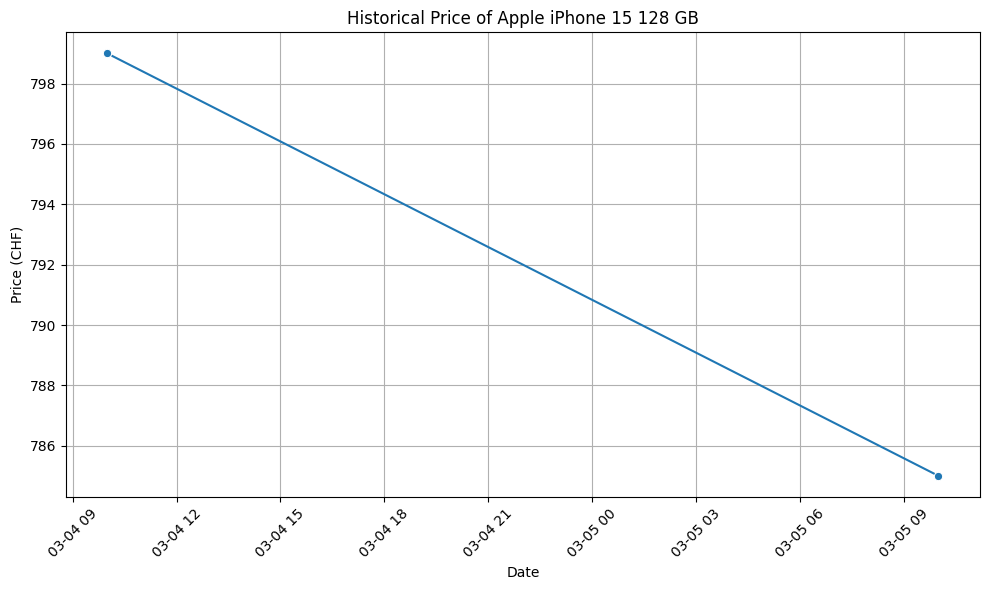

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the historical price
plt.figure(figsize=(10, 6))
sns.lineplot(x='timestamp', y='price', data=df_history, marker='o')
plt.title(f'Historical Price of {df_history.loc[0, "product_name"]}')
plt.xlabel('Date')
plt.ylabel('Price (CHF)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()